In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import shap
import joblib

In [27]:
model_path = r"C:/Users/DAKSH/Downloads/customer-churn-prediction-advanced/models/churn_model.pkl"
data_path = r"C:/Users/DAKSH/Downloads/customer-churn-prediction-advanced/models/processed_data.pkl"
model = joblib.load(model_path)
X_train, X_test, y_train, y_test = joblib.load(data_path)
print("Model and data loaded successfully!")

Model and data loaded successfully!


In [28]:
#Create SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

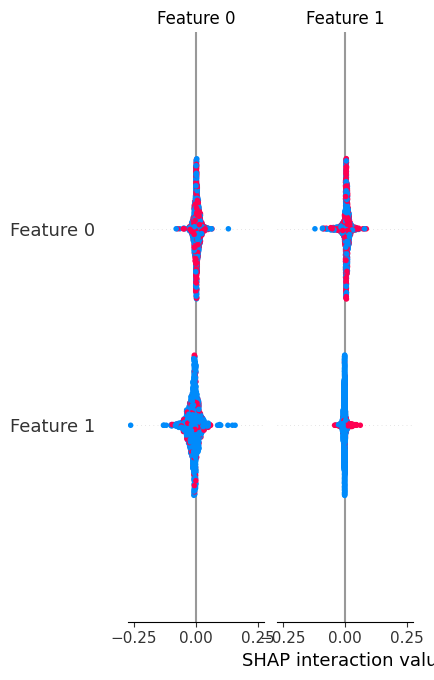

In [29]:
#SHAP Summary Plot (Most Important Plot)
shap.summary_plot(shap_values, X_test)

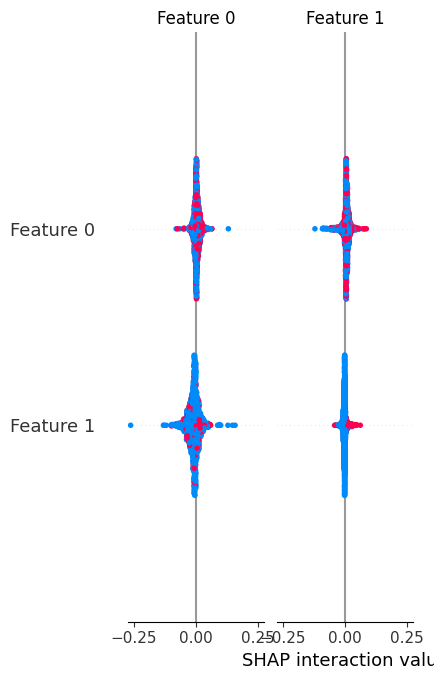

In [30]:
#Feature Importance (SHAP)
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [34]:
# SHAP Explainability Section
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Convert numpy array to dataframe
X_test_df = pd.DataFrame(X_test)

# Initialize explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(
    X_test_df,
    check_additivity=False
)

# Binary classification → class 1
shap_values_class1 = shap_values[1]
shap.summary_plot(
    shap_values_class1,
    X_test_df
)
shap.summary_plot(
    shap_values_class1,
    X_test_df,
    plot_type="bar"
)
shap.dependence_plot(
    0,
    shap_values_class1,
    X_test_df
)
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_class1[0],
        base_values=explainer.expected_value[1],
        data=X_test_df.iloc[0],
        feature_names=X_test_df.columns
    )
)
shap.initjs()
shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[0],
    X_test_df.iloc[0]
)

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [ ]:
#Single Customer Prediction Explanation
shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values[1][0],
    X_test[0]
)

In [ ]:
#Waterfall Plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][0],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[0]
    )
)

In [ ]:
#Top Churn Drivers Table
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": np.abs(shap_values[1]).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Importance",
    ascending=False
)

shap_importance.head(10)

In [ ]:
#Churn Drivers Visualization
plt.figure(figsize=(9,5))

sns.barplot(
    data=shap_importance.head(10),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Drivers of Customer Churn", fontsize=16, fontweight="bold")

plt.xlabel("Average SHAP Impact")

plt.tight_layout()

plt.show()